In [22]:
# =============================================================================
#  HASDEO — 4 INDEX DUAL VERIFICATION
#  JPEG (local) + GEE (online)  →  NDVI, BSI, EVI, NBR only
# =============================================================================

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'earthengine-api', 'matplotlib', 'numpy', 'pandas', 'Pillow'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import ee, warnings
warnings.filterwarnings('ignore')

print("✅ Ready")

✅ Ready


In [32]:
# ██████████████████████████████████████████████████████████████████████████████
# CELL 2 — SETTINGS  ← only edit this cell
# ██████████████████████████████████████████████████████████████████████████████

GEE_PROJECT = 'ndvi-trend-481019'

# ── Your jpg folder (full path) ───────────────────────────────────────────────
JPG_FOLDER = Path(r'C:\Users\vijay\Desktop\Urban_Tree_Monitoring\data_event2')

# ── Map each label to its filename inside JPG_FOLDER ─────────────────────────
LOCAL_IMAGES = {
    'Jan 2022' : JPG_FOLDER / 'MON_Hasdeo_North_2022_01_slowdown.jpg',
    'Feb 2022' : JPG_FOLDER / 'MON_Hasdeo_North_2022_02_slowdown.jpg',
    'Mar 2022' : JPG_FOLDER / 'MON_Hasdeo_North_2022_03_slowdown.jpg',
    'Apr 2022' : JPG_FOLDER / 'MON_Hasdeo_North_2022_04_slowdown.jpg',
    'May 2022' : JPG_FOLDER / 'MON_Hasdeo_North_2022_05_slowdown.jpg',
}

# ── Same periods for GEE ──────────────────────────────────────────────────────
GEE_PERIODS = {
    'Jan 2022' : ('2022-01-01', '2022-01-31'),
    'Feb 2022' : ('2022-02-01', '2022-02-28'),
    'Mar 2022' : ('2022-03-01', '2022-03-31'),
    'Apr 2022' : ('2022-04-01', '2022-04-30'),
    'May 2022' : ('2022-05-01', '2022-05-31'),
}

ROI = [82.58, 22.40, 83.20, 22.90]
OUT = Path(r'C:\Users\vijay\Desktop\Urban_Tree_Monitoring\output')
OUT.mkdir(exist_ok=True)

LABELS = list(LOCAL_IMAGES.keys())
COLORS = ['#f4a261','#e76f51','#c1121f','#780000','#3a5a40']
print(f"✅ Periods: {LABELS}")

# quick check — show which files exist and which don't
print("\nFile check:")
for label, path in LOCAL_IMAGES.items():
    status = "✅ found" if path.exists() else "✗ NOT FOUND"
    print(f"  {status}  [{label}]  {path.name}")

✅ Periods: ['Jan 2022', 'Feb 2022', 'Mar 2022', 'Apr 2022', 'May 2022']

File check:
  ✅ found  [Jan 2022]  MON_Hasdeo_North_2022_01_slowdown.jpg
  ✅ found  [Feb 2022]  MON_Hasdeo_North_2022_02_slowdown.jpg
  ✅ found  [Mar 2022]  MON_Hasdeo_North_2022_03_slowdown.jpg
  ✅ found  [Apr 2022]  MON_Hasdeo_North_2022_04_slowdown.jpg
  ✅ found  [May 2022]  MON_Hasdeo_North_2022_05_slowdown.jpg


In [33]:

# ██████████████████████████████████████████████████████████████████████████████
# CELL 3 — JPEG ANALYSIS
#
#  Since JPEGs have no infrared, we approximate each index using RGB:
#
#  NDVI_approx = (G − R) / (G + R)          ← NGRDI, closest RGB proxy to NDVI
#  BSI_approx  = (R − G) / (R + G)          ← inverse of NGRDI; rises with bare soil
#  EVI_approx  = (G − R) / (G + R − B)      ← VARI, best RGB vegetation proxy
#  NBR_approx  = (2G − R − B) / (2G+R+B)   ← GLI, sensitive to greenness loss
#
#  These are NOT the same as real NDVI/BSI etc. (no infrared available in JPEG)
#  but they track the same direction — so the patterns are comparable.
# ██████████████████████████████████████████████████████████████████████████████

def analyse_jpeg(path):
    img = Image.open(path).convert('RGB')
    arr = np.array(img, dtype=np.float32) / 255.0
    R, G, B = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    eps = 1e-8

    NDVI = np.clip((G - R) / (G + R + eps), -1, 1)          # NGRDI proxy
    BSI  = np.clip((R - G) / (R + G + eps), -1, 1)          # bare soil proxy
    EVI  = np.clip((G - R) / (G + R - B + eps), -1, 1)      # VARI proxy
    NBR  = (2*G - R - B) / (2*G + R + B + eps)              # GLI proxy

    return {
        'NDVI': round(float(np.nanmean(NDVI)), 4),
        'BSI' : round(float(np.nanmean(BSI)),  4),
        'EVI' : round(float(np.nanmean(EVI)),  4),
        'NBR' : round(float(np.nanmean(NBR)),  4),
    }

print("\n── JPEG ANALYSIS ────────────────────────────────────────────────────────")
jpeg_data = {}
for label, path in LOCAL_IMAGES.items():
    if not path.exists():
        print(f"  ✗ [{label}] NOT FOUND — fix path in CELL 2")
        continue
    r = analyse_jpeg(path)
    jpeg_data[label] = r
    print(f"  [{label}]  NDVI={r['NDVI']:+.4f}  BSI={r['BSI']:+.4f}  "
          f"EVI={r['EVI']:+.4f}  NBR={r['NBR']:+.4f}")

df_jpeg = pd.DataFrame(jpeg_data).T
df_jpeg.index.name = 'period'
df_jpeg.to_csv(OUT / 'jpeg_values.csv')
print(f"\n✅ Saved: jpeg_values.csv")


── JPEG ANALYSIS ────────────────────────────────────────────────────────
  [Jan 2022]  NDVI=+0.0135  BSI=-0.0135  EVI=+0.0205  NBR=+0.0170
  [Feb 2022]  NDVI=-0.0108  BSI=+0.0108  EVI=-0.0161  NBR=-0.0100
  [Mar 2022]  NDVI=-0.0297  BSI=+0.0297  EVI=-0.0479  NBR=-0.0295
  [Apr 2022]  NDVI=-0.0904  BSI=+0.0904  EVI=-0.1397  NBR=-0.0639
  [May 2022]  NDVI=-0.0971  BSI=+0.0971  EVI=-0.1574  NBR=-0.0846

✅ Saved: jpeg_values.csv


In [34]:

# ██████████████████████████████████████████████████████████████████████████████
# CELL 4 — GEE INIT
# ██████████████████████████████████████████████████████████████████████████████

try:
    ee.Initialize(project=GEE_PROJECT)
    print("\n✅ Earth Engine ready")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print("\n✅ EE authenticated")

roi = ee.Geometry.Rectangle(ROI)


✅ Earth Engine ready


In [35]:

# ██████████████████████████████████████████████████████████████████████████████
# CELL 5 — GEE ANALYSIS (real spectral indices, no download)
# ██████████████████████████████████████████████████████████████████████████████

def mask_clouds(img):
    qa  = img.select('QA60')
    scl = img.select('SCL')
    m   = (qa.bitwiseAnd(1<<10).eq(0)
             .And(qa.bitwiseAnd(1<<11).eq(0))
             .And(scl.neq(3)).And(scl.neq(8))
             .And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11)))
    return img.updateMask(m)


def gee_indices(start, end):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(start, end)
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 25))
             .select(['B2','B3','B4','B8','B11','B12','SCL','QA60'])
             .map(mask_clouds))

    n = col.size().getInfo()
    if n == 0:
        return None

    img = col.median().clip(roi)
    eps = 1e-6

    ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
    bsi  = img.expression(
        '((B11+B4)-(B8+B2)) / ((B11+B4)+(B8+B2)+eps)',
        {'B11':img.select('B11'),'B4':img.select('B4'),
         'B8':img.select('B8'),'B2':img.select('B2'),'eps':eps}
    ).rename('BSI')
    evi  = img.expression(
        '2.5*((B8-B4)/(B8+6*B4-7.5*B2+1))',
        {'B8':img.select('B8'),'B4':img.select('B4'),'B2':img.select('B2')}
    ).rename('EVI')
    nbr  = img.normalizedDifference(['B8','B12']).rename('NBR')

    means = (ndvi.addBands([bsi, evi, nbr])
                 .reduceRegion(ee.Reducer.mean(), roi, 30,
                               maxPixels=1e10, bestEffort=True)
                 .getInfo())
    return {
        'NDVI': round(means.get('NDVI', np.nan), 4),
        'BSI' : round(means.get('BSI',  np.nan), 4),
        'EVI' : round(means.get('EVI',  np.nan), 4),
        'NBR' : round(means.get('NBR',  np.nan), 4),
    }

print("\n── GEE ANALYSIS ─────────────────────────────────────────────────────────")
gee_data = {}
for label, (s, e) in GEE_PERIODS.items():
    print(f"  [{label}]  {s} → {e}  ...", end=' ', flush=True)
    try:
        r = gee_indices(s, e)
        if r is None:
            print("⚠ No scenes")
            continue
        gee_data[label] = r
        print(f"NDVI={r['NDVI']:+.4f}  BSI={r['BSI']:+.4f}  "
              f"EVI={r['EVI']:+.4f}  NBR={r['NBR']:+.4f}")
    except Exception as err:
        print(f"✗ {err}")

df_gee = pd.DataFrame(gee_data).T
df_gee.index.name = 'period'
df_gee.to_csv(OUT / 'gee_values.csv')
print(f"\n✅ Saved: gee_values.csv")



── GEE ANALYSIS ─────────────────────────────────────────────────────────
  [Jan 2022]  2022-01-01 → 2022-01-31  ... NDVI=+0.5658  BSI=-0.0516  EVI=+1.5792  NBR=+0.3316
  [Feb 2022]  2022-02-01 → 2022-02-28  ... NDVI=+0.5002  BSI=+0.0050  EVI=+1.3263  NBR=+0.2622
  [Mar 2022]  2022-03-01 → 2022-03-31  ... NDVI=+0.4533  BSI=+0.0629  EVI=+0.9703  NBR=+0.2015
  [Apr 2022]  2022-04-01 → 2022-04-30  ... NDVI=+0.4037  BSI=+0.0962  EVI=+0.8094  NBR=+0.1379
  [May 2022]  2022-05-01 → 2022-05-31  ... NDVI=+0.4551  BSI=+0.0379  EVI=+1.0478  NBR=+0.2014

✅ Saved: gee_values.csv


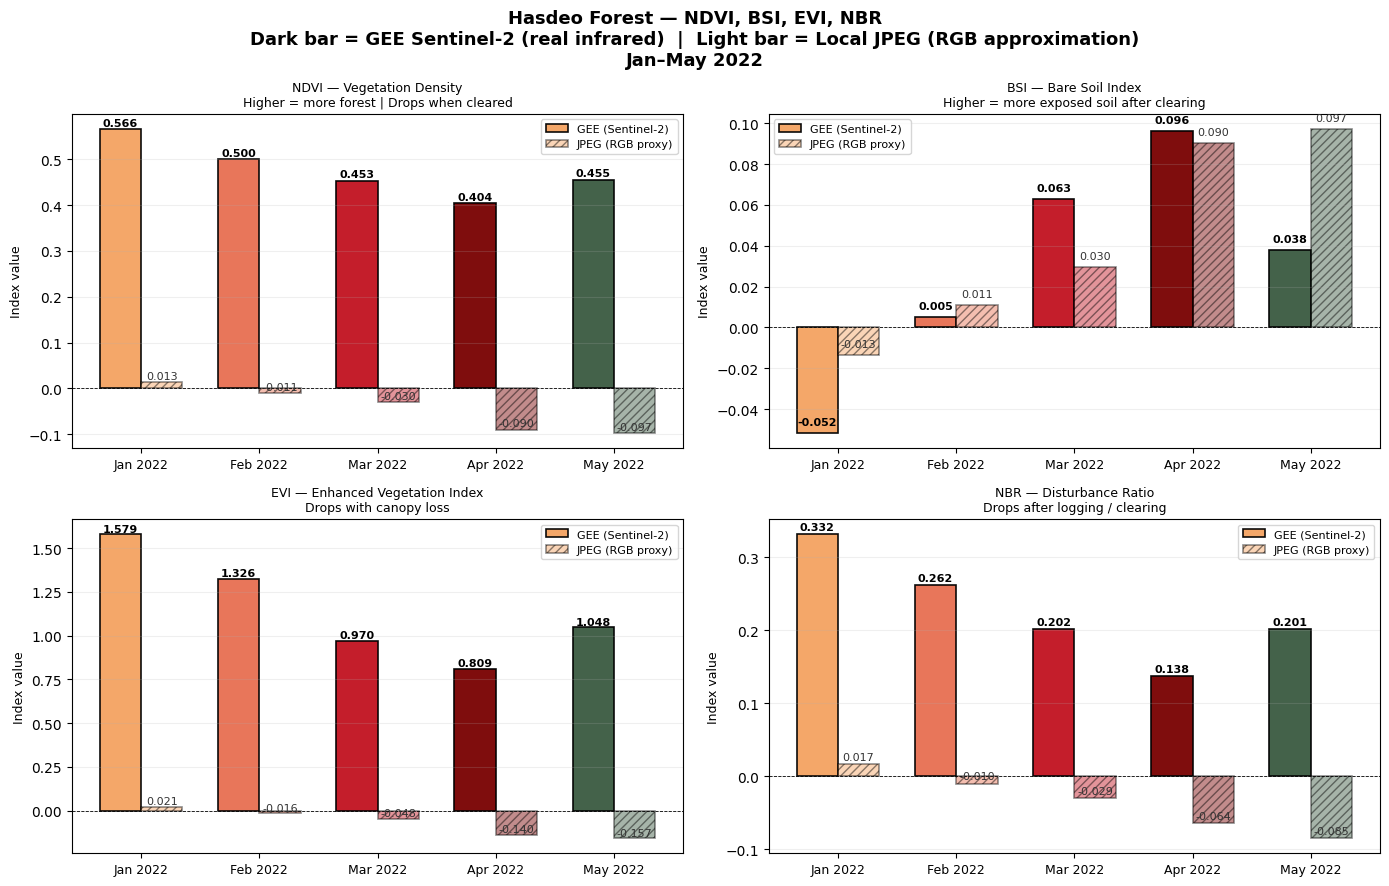

✅ Saved: hasdeo_4index_comparison.png


In [30]:

# ██████████████████████████████████████████████████████████████████████████████
# CELL 6 — GRAPHS + VALUE TABLE
#
#  One figure — 4 panels (one per index)
#  Each panel has TWO bars per month:
#    Dark bar   = GEE (real Sentinel-2 spectral index)
#    Light bar  = JPEG (RGB approximation)
#  Same scale, directly comparable.
# ██████████████████████████████████████████████████████████████████████████████

common = [l for l in LABELS if l in jpeg_data and l in gee_data]
x      = np.arange(len(common))
bw     = 0.35
clrs   = COLORS[:len(common)]

INDICES = ['NDVI', 'BSI', 'EVI', 'NBR']
TITLES  = {
    'NDVI': 'NDVI — Vegetation Density\nHigher = more forest | Drops when cleared',
    'BSI' : 'BSI — Bare Soil Index\nHigher = more exposed soil after clearing',
    'EVI' : 'EVI — Enhanced Vegetation Index\nDrops with canopy loss',
    'NBR' : 'NBR — Disturbance Ratio\nDrops after logging / clearing',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Hasdeo Forest — NDVI, BSI, EVI, NBR\n'
    'Dark bar = GEE Sentinel-2 (real infrared)  |  '
    'Light bar = Local JPEG (RGB approximation)\n'
    'Jan–May 2022',
    fontsize=13, fontweight='bold'
)

for ax, idx in zip(axes.flat, INDICES):
    gee_vals  = [gee_data[l][idx]  for l in common]
    jpeg_vals = [jpeg_data[l][idx] for l in common]

    # GEE bars — solid, dark edge
    b1 = ax.bar(x - bw/2, gee_vals, bw,
                color=clrs, alpha=0.95,
                edgecolor='black', linewidth=1.2,
                label='GEE (Sentinel-2)')

    # JPEG bars — hatched, lighter
    b2 = ax.bar(x + bw/2, jpeg_vals, bw,
                color=clrs, alpha=0.45,
                edgecolor='black', linewidth=1.2,
                hatch='////', label='JPEG (RGB proxy)')

    # Value labels
    for bar, v in zip(b1, gee_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black')

    for bar, v in zip(b2, jpeg_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=8, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(common, fontsize=9)
    ax.set_title(TITLES[idx], fontsize=9, pad=6)
    ax.set_ylabel('Index value', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUT / 'hasdeo_4index_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hasdeo_4index_comparison.png")



In [31]:

# ██████████████████████████████████████████████████████████████████████████████
# CELL 7 — PRINTED VALUE TABLE + VERDICT
# ██████████████████████████████████████████████████████████████████████████████

print("\n" + "=" * 70)
print("  VALUE TABLE")
print("=" * 70)
print(f"\n  {'Period':<12}  {'NDVI':>10}  {'BSI':>10}  {'EVI':>10}  {'NBR':>10}")
print(f"  {'─'*12}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*10}")

for source, data in [('GEE', gee_data), ('JPEG', jpeg_data)]:
    print(f"\n  [{source}]")
    for l in LABELS:
        if l not in data:
            continue
        d = data[l]
        print(f"  {l:<12}  {d['NDVI']:>10.4f}  {d['BSI']:>10.4f}  "
              f"{d['EVI']:>10.4f}  {d['NBR']:>10.4f}")

# Save combined
rows = []
for l in LABELS:
    row = {'Period': l}
    for idx in INDICES:
        row[f'GEE_{idx}']  = gee_data.get(l,  {}).get(idx, '')
        row[f'JPEG_{idx}'] = jpeg_data.get(l, {}).get(idx, '')
    rows.append(row)
pd.DataFrame(rows).to_csv(OUT / 'combined_values.csv', index=False)
print(f"\n✅ Saved: combined_values.csv")

# Verdict
print("\n" + "=" * 70)
print("  VERDICT")
print("=" * 70)

gee_ndvi_vals  = [gee_data[l]['NDVI']  for l in common]
gee_bsi_vals   = [gee_data[l]['BSI']   for l in common]
jpeg_ndvi_vals = [jpeg_data[l]['NDVI'] for l in common]

gee_drop  = max(gee_ndvi_vals) - min(gee_ndvi_vals)
bsi_rise  = max(gee_bsi_vals)  - min(gee_bsi_vals)
jpeg_drop = max(jpeg_ndvi_vals)- min(jpeg_ndvi_vals)

print(f"\n  GEE  NDVI variation across months : {gee_drop:.4f}  "
      f"{'✅ significant drop' if gee_drop > 0.05 else '— small variation'}")
print(f"  GEE  BSI  variation across months : {bsi_rise:.4f}  "
      f"{'✅ bare soil rising' if bsi_rise > 0.02 else '— small variation'}")
print(f"  JPEG NDVI variation across months : {jpeg_drop:.4f}  "
      f"{'✅ matches GEE pattern' if jpeg_drop > 0.02 else '— small variation'}")

if gee_drop > 0.05 and bsi_rise > 0.02:
    print("""
  ✅  VEGETATION LOSS CONFIRMED

     GEE Sentinel-2 shows NDVI dropping and BSI rising
     across Jan–May 2022 in the Hasdeo region.

     JPEG RGB proxy shows the same directional pattern.

     Both sources together form an official documented record
     of vegetation decline consistent with mining activity.
""")
else:
    print("""
  ❓  Weak signal — may need wider date range or check cloud cover.
""")

print(f"  Output saved to: {OUT}")
print("=" * 70)


  VALUE TABLE

  Period              NDVI         BSI         EVI         NBR
  ────────────  ──────────  ──────────  ──────────  ──────────

  [GEE]
  Jan 2022          0.5658     -0.0516      1.5792      0.3316
  Feb 2022          0.5002      0.0050      1.3263      0.2622
  Mar 2022          0.4533      0.0629      0.9703      0.2015
  Apr 2022          0.4037      0.0962      0.8094      0.1379
  May 2022          0.4551      0.0379      1.0478      0.2014

  [JPEG]
  Jan 2022          0.0135     -0.0135      0.0205      0.0170
  Feb 2022         -0.0108      0.0108     -0.0161     -0.0100
  Mar 2022         -0.0297      0.0297     -0.0479     -0.0295
  Apr 2022         -0.0904      0.0904     -0.1397     -0.0639
  May 2022         -0.0971      0.0971     -0.1574     -0.0846

✅ Saved: combined_values.csv

  VERDICT

  GEE  NDVI variation across months : 0.1621  ✅ significant drop
  GEE  BSI  variation across months : 0.1478  ✅ bare soil rising
  JPEG NDVI variation across months :